# End-to-End Data I/O, Web Scraping, API, and SQL Analytics Pipeline

This notebook implements an automated E-Commerce data pipeline integrating:

- Module 1: Web Scraping using BeautifulSoup and Regex Text Preprocessing
- Module 2: REST API extraction, JSON parsing, numerical cleaning, and missing value imputation
- Module 3: SQLite relational database setup, table schemas, and data insertion
- Module 4: SQL data preprocessing, validation, joins, and business analytics

## Project Objective

Build an end-to-end pipeline that extracts product data,
cleans and enriches the data, stores it in a relational database,
and performs SQL-based business analytics.

In [1]:
# Cell 2: Web Scraping and Text Preprocessing

import re
import os
import sqlite3
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

# --------------------------------------------------
# 1. Simulated HTML Web Page
# --------------------------------------------------

html_doc = """
<html>
<body>

<div class="product">

    <h2 class="title">
        Wireless Noise-Canceling Headphones!
    </h2>

    <p class="description">
        Features <strong>active noise cancellation</strong>,
        20h battery, & bluetooth 5.0.
    </p>

    <span class="price">$199.99</span>

    <span class="stock">
        In Stock (15)
    </span>

</div>


<div class="product">

    <h2 class="title">
        Smartwatch Fitness Tracker...
    </h2>

    <p class="description">
        Tracks heart rate, sleep steps & GPS navigation.
    </p>

    <span class="price">$149.50</span>

    <span class="stock">
        Out of Stock
    </span>

</div>


<div class="product">

    <h2 class="title">
        Mechanical Gaming Keyboard
    </h2>

    <p class="description">
        RGB backlit switches with ergonomic wrist rest.
    </p>

    <span class="price">$89.00</span>

    <span class="stock">
        In Stock (8)
    </span>

</div>

</body>
</html>
"""

# --------------------------------------------------
# 2. Parse HTML
# --------------------------------------------------

soup = BeautifulSoup(html_doc, "html.parser")

products = []

for item in soup.find_all("div", class_="product"):

    raw_title = item.find("h2", class_="title").get_text()

    raw_desc = item.find(
        "p",
        class_="description"
    ).get_text()

    raw_price = item.find(
        "span",
        class_="price"
    ).get_text()

    raw_stock = item.find(
        "span",
        class_="stock"
    ).get_text()

    # --------------------------------------------------
    # 3. Text Preprocessing
    # --------------------------------------------------

    clean_title = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        raw_title
    ).strip()

    clean_desc = re.sub(
        r"\s+",
        " ",
        raw_desc
    ).strip()

    price_val = float(
        re.sub(
            r"[^\d.]",
            "",
            raw_price
        )
    )

    products.append({
        "product_name": clean_title,
        "description": clean_desc,
        "price_usd": price_val,
        "raw_stock_status": raw_stock.strip()
    })


# --------------------------------------------------
# 4. Convert to DataFrame
# --------------------------------------------------

df_scraped = pd.DataFrame(products)


# --------------------------------------------------
# 5. Create data directory
# --------------------------------------------------

os.makedirs("../data", exist_ok=True)


# --------------------------------------------------
# 6. Save raw scraped data
# --------------------------------------------------

df_scraped.to_csv(
    "../data/raw_web_scraped_products.csv",
    index=False
)


# --------------------------------------------------
# 7. Display results
# --------------------------------------------------

print(
    "--- Module 1 Complete: "
    "Scraped & Text Preprocessed Data ---"
)

display(df_scraped)

--- Module 1 Complete: Scraped & Text Preprocessed Data ---


,product_name,description,price_usd,raw_stock_status
0,Wireless NoiseCanceling Headphones,"Features active noise cancellation, 20h batter...",199.99,In Stock (15)
1,Smartwatch Fitness Tracker,"Tracks heart rate, sleep steps & GPS navigation.",149.50,Out of Stock
2,Mechanical Gaming Keyboard,RGB backlit switches with ergonomic wrist rest.,89.00,In Stock (8)


In [2]:
# Cell 3: API Extraction & Numerical Cleaning

# --------------------------------------------------
# 1. Simulated API FX Rates
# --------------------------------------------------

api_response = {
    "base": "USD",
    "rates": {
        "USD": 1.0,
        "EUR": 0.92,
        "GBP": 0.78,
        "INR": 83.15
    }
}


# --------------------------------------------------
# 2. Save API response as JSON
# --------------------------------------------------

import json

with open(
    "../data/api_exchange_rates.json",
    "w"
) as f:
    json.dump(
        api_response,
        f,
        indent=4
    )


# --------------------------------------------------
# 3. USD → EUR Conversion
# --------------------------------------------------

fx_rate_eur = api_response["rates"]["EUR"]

df_scraped["price_eur"] = (
    df_scraped["price_usd"] * fx_rate_eur
).round(2)


# --------------------------------------------------
# 4. Extract Stock Quantity
# --------------------------------------------------

df_scraped["stock_quantity"] = (
    df_scraped["raw_stock_status"]
    .str.extract(r"(\d+)")
    .astype(float)
)


# --------------------------------------------------
# 5. Missing Value Imputation
# --------------------------------------------------

df_scraped["stock_quantity"] = (
    df_scraped["stock_quantity"]
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# 6. Numerical Validation
# --------------------------------------------------

assert (
    df_scraped["price_usd"] > 0
).all(), "Validation Error: Invalid price detected!"


# --------------------------------------------------
# 7. Display results
# --------------------------------------------------

print(
    "--- Module 2 Complete: "
    "API Enriched & Numerically Cleaned Data ---"
)

display(
    df_scraped[
        [
            "product_name",
            "price_usd",
            "price_eur",
            "stock_quantity"
        ]
    ]
)

--- Module 2 Complete: API Enriched & Numerically Cleaned Data ---


,product_name,price_usd,price_eur,stock_quantity
0,Wireless NoiseCanceling Headphones,199.99,183.99,15
1,Smartwatch Fitness Tracker,149.50,137.54,0
2,Mechanical Gaming Keyboard,89.00,81.88,8


In [3]:
# Cell 4: Database Storage with SQLite & Schema Creation

# --------------------------------------------------
# 1. Database Connection
# --------------------------------------------------

db_path = "../data/ecommerce_pipeline.db"

conn = sqlite3.connect(db_path)

cursor = conn.cursor()


# --------------------------------------------------
# 2. Enable Foreign Keys
# --------------------------------------------------

cursor.execute(
    "PRAGMA foreign_keys = ON;"
)


# --------------------------------------------------
# 3. Create Products Table
# --------------------------------------------------

cursor.execute("""
CREATE TABLE IF NOT EXISTS products (

    product_id INTEGER PRIMARY KEY AUTOINCREMENT,

    product_name TEXT NOT NULL,

    description TEXT,

    price_usd REAL CHECK(price_usd > 0),

    stock_quantity INTEGER DEFAULT 0

);
""")


# --------------------------------------------------
# 4. Create Orders Table
# --------------------------------------------------

cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (

    order_id INTEGER PRIMARY KEY AUTOINCREMENT,

    product_id INTEGER,

    order_date DATE,

    quantity_sold INTEGER,

    customer_region TEXT,

    FOREIGN KEY (product_id)
        REFERENCES products(product_id)

);
""")


# --------------------------------------------------
# 5. Commit Schema
# --------------------------------------------------

conn.commit()


# --------------------------------------------------
# 6. Insert Product Data
# --------------------------------------------------

for _, row in df_scraped.iterrows():

    cursor.execute("""
    INSERT INTO products
    (
        product_name,
        description,
        price_usd,
        stock_quantity
    )

    VALUES (?, ?, ?, ?)
    """,
    (
        row["product_name"],
        row["description"],
        row["price_usd"],
        row["stock_quantity"]
    ))


# --------------------------------------------------
# 7. Mock Orders
# --------------------------------------------------

orders_data = [

    (1, "2026-01-15", 3, "North America"),

    (1, "2026-01-18", 2, "Europe"),

    (2, "2026-01-20", 1, "Asia-Pacific"),

    (3, "2026-01-22", 5, "North America"),

    (3, "2026-01-25", 2, "Europe")
]


# --------------------------------------------------
# 8. Insert Orders
# --------------------------------------------------

cursor.executemany("""
INSERT INTO orders
(
    product_id,
    order_date,
    quantity_sold,
    customer_region
)

VALUES (?, ?, ?, ?)
""", orders_data)


# --------------------------------------------------
# 9. Commit
# --------------------------------------------------

conn.commit()


print(
    "--- Module 3 Complete: "
    "SQLite Database Configured & Loaded ---"
)

--- Module 3 Complete: SQLite Database Configured & Loaded ---


In [4]:
# Check Products Table

df_products = pd.read_sql_query(
    "SELECT * FROM products",
    conn
)

display(df_products)

,product_id,product_name,description,price_usd,stock_quantity
0,1,Wireless NoiseCanceling Headphones,"Features active noise cancellation, 20h batter...",199.99,15
1,2,Smartwatch Fitness Tracker,"Tracks heart rate, sleep steps & GPS navigation.",149.50,0
2,3,Mechanical Gaming Keyboard,RGB backlit switches with ergonomic wrist rest.,89.00,8


In [5]:
# Check Orders Table

df_orders = pd.read_sql_query(
    "SELECT * FROM orders",
    conn
)

display(df_orders)

,order_id,product_id,order_date,quantity_sold,customer_region
0,1,1,2026-01-15,3,North America
1,2,1,2026-01-18,2,Europe
2,3,2,2026-01-20,1,Asia-Pacific
3,4,3,2026-01-22,5,North America
4,5,3,2026-01-25,2,Europe


In [6]:
# Cell 5: SQL Data Validation

validation_query = """

SELECT

    p.product_id,

    p.product_name,

    COUNT(o.order_id) AS total_orders,

    COALESCE(
        SUM(o.quantity_sold),
        0
    ) AS units_sold

FROM products p

LEFT JOIN orders o

    ON p.product_id = o.product_id

GROUP BY

    p.product_id,

    p.product_name;

"""

df_validation = pd.read_sql_query(
    validation_query,
    conn
)

print(
    "--- SQL Data Validation Check ---"
)

display(df_validation)

--- SQL Data Validation Check ---


,product_id,product_name,total_orders,units_sold
0,1,Wireless NoiseCanceling Headphones,2,5
1,2,Smartwatch Fitness Tracker,1,1
2,3,Mechanical Gaming Keyboard,2,7


In [7]:
# Cell 6: SQL Revenue Analytics

analytics_query = """

SELECT

    p.product_name,

    o.customer_region,

    SUM(o.quantity_sold) AS total_quantity,

    ROUND(
        SUM(
            o.quantity_sold * p.price_usd
        ),
        2
    ) AS total_revenue_usd

FROM orders o

INNER JOIN products p

    ON o.product_id = p.product_id

GROUP BY

    p.product_name,

    o.customer_region

ORDER BY

    total_revenue_usd DESC;

"""

df_analytics = pd.read_sql_query(
    analytics_query,
    conn
)

print(
    "--- SQL Inner Join Revenue Analytics ---"
)

display(df_analytics)

--- SQL Inner Join Revenue Analytics ---


,product_name,customer_region,total_quantity,total_revenue_usd
0,Wireless NoiseCanceling Headphones,North America,3,599.97
1,Mechanical Gaming Keyboard,North America,5,445.00
2,Wireless NoiseCanceling Headphones,Europe,2,399.98
3,Mechanical Gaming Keyboard,Europe,2,178.00
4,Smartwatch Fitness Tracker,Asia-Pacific,1,149.50


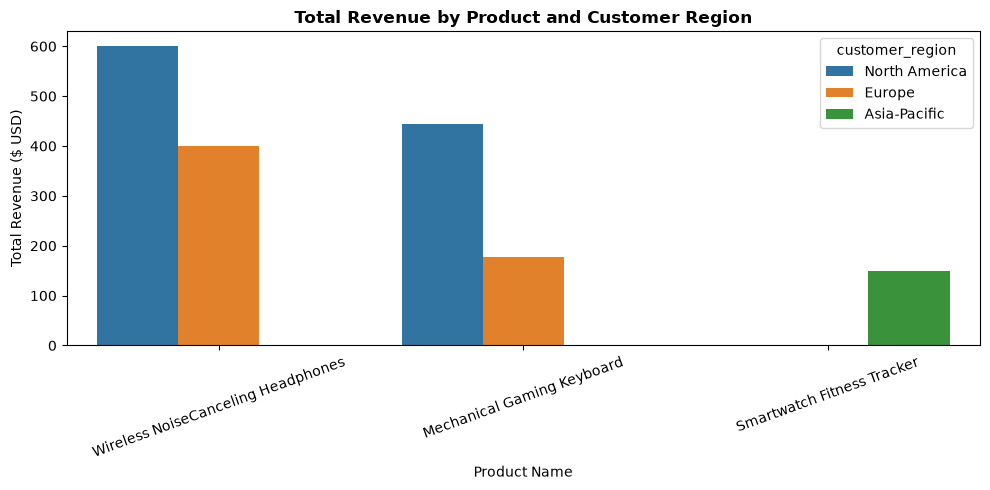

In [9]:
# Cell 7: Revenue Visualization

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(
    "../visuals",
    exist_ok=True
)


plt.figure(
    figsize=(10, 5)
)


sns.barplot(
    data=df_analytics,
    x="product_name",
    y="total_revenue_usd",
    hue="customer_region"
)


plt.title(
    "Total Revenue by Product and Customer Region",
    fontweight="bold"
)

plt.xlabel(
    "Product Name"
)

plt.ylabel(
    "Total Revenue ($ USD)"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()


plt.savefig(
    "../visuals/sql_join_analytics.png",
    dpi=300
)


plt.show()

In [10]:
# Close SQLite connection

conn.close()

print("Database connection closed.")

Database connection closed.
